# Notebook 09: Real-Time Streaming Demo

Simulates a real-time ECG monitoring system using **BaselineCNN** — the windowed
model that was specifically designed for 2.5-second window inference.

A 10-second ECG record is fed in streaming fashion: one 2.5-second window at a time
with 50% overlap (125 samples = 1.25 seconds per step).  Predictions accumulate via
running mean, showing how the model's confidence evolves as more signal arrives.

Also benchmarks per-window latency on GPU vs CPU to confirm real-time feasibility
(real-time = inference faster than the window stride of 1.25 seconds).

In [1]:
import sys, os, json, time, warnings
sys.path.append('../')
os.environ['TRANSFORMERS_OFFLINE']          = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
warnings.filterwarnings('ignore')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import wfdb

from src.utils.config              import CFG
from src.inference.loaders         import load_baseline_cnn
from src.preprocessing.label_utils import load_all_labels
from src.preprocessing.preprocess  import preprocess_record, bandpass_filter, normalize_signal

DATA_PATH    = CFG['data']['path']
RESULTS      = CFG['paths']['results']
FIGURES      = CFG['paths']['figures']
SUPERCLASSES = CFG['data']['superclasses']
WINDOW_SIZE  = CFG['data']['window_size']   # 250 samples = 2.5 s
STRIDE       = CFG['data']['stride']        # 125 samples = 1.25 s
FS           = CFG['data']['sampling_rate'] # 100 Hz
CLASS_COLORS = ['steelblue', 'tomato', 'darkorange', 'mediumseagreen', 'mediumpurple']

os.makedirs(FIGURES, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
else:
    print('GPU : not available -- running on CPU')

GPU : NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
print('Loading BaselineCNN...')
cnn_model, _ = load_baseline_cnn()
cnn_model.eval()
print('Loaded.')

# Count parameters for reference
total = sum(p.numel() for p in cnn_model.parameters())
print(f'Parameters : {total:,}')

# Confirm expected input shape: (B, 12, 250)
with torch.no_grad():
    dummy = torch.randn(1, 12, 250)
    out   = cnn_model(dummy)
    assert out.shape == (1, 5), f'Unexpected output shape: {out.shape}'
print('Forward pass OK  |  input (1,12,250) -> output (1,5)')

Loading BaselineCNN...
Loaded.
Parameters : 46,309
Forward pass OK  |  input (1,12,250) -> output (1,5)


In [3]:
# Pick 3 test records: one NORM, one MI, one multi-label
Y       = load_all_labels(DATA_PATH + 'ptbxl_database.csv',
                          DATA_PATH + 'scp_statements.csv')
test_df = Y[Y.strat_fold == 10].reset_index()

def find_record(df, required_class, exclude_class=None):
    """Find first test record that contains required_class."""
    cls_idx = SUPERCLASSES.index(required_class)
    for _, row in df.iterrows():
        if row['label_vec'][cls_idx] == 1:
            if exclude_class is None:
                return row
            ex_idx = SUPERCLASSES.index(exclude_class)
            if row['label_vec'][ex_idx] == 0:
                return row
    return df.iloc[0]

demo_records = {
    'NORM': find_record(test_df, 'NORM'),
    'MI':   find_record(test_df, 'MI',  exclude_class='NORM'),
    'HYP':  find_record(test_df, 'HYP', exclude_class='NORM'),
}

for label, row in demo_records.items():
    true_cls = [SUPERCLASSES[i] for i, v in enumerate(row['label_vec']) if v == 1]
    print(f'  {label:6}  ->  true labels: {true_cls}  |  file: {row["filename_lr"]}')

Records with valid labels: 21388
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5235 (24.5%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
  NORM    ->  true labels: ['NORM']  |  file: records100/00000/00009_lr
  MI      ->  true labels: ['MI']  |  file: records100/00000/00063_lr
  HYP     ->  true labels: ['MI', 'STTC', 'CD', 'HYP']  |  file: records100/00000/00162_lr


In [4]:
def stream_inference(model, signal_np, dev):
    """
    Simulate streaming: process each window as it arrives.

    signal_np : (1000, 12) raw ECG (time-first)
    Returns:
        window_probs  : (n_windows, 5) per-window sigmoid probabilities
        running_probs : (n_windows, 5) running mean up to each window
        latencies_ms  : (n_windows,)  per-window inference latency in ms
        window_times  : (n_windows,)  start time (seconds) of each window
    """
    # Preprocess full signal once
    proc = bandpass_filter(signal_np)
    proc = normalize_signal(proc).astype(np.float32)  # (1000, 12)

    model.eval()
    model.to(dev)

    window_probs  = []
    latencies_ms  = []
    window_times  = []

    start = 0
    while start + WINDOW_SIZE <= proc.shape[0]:
        win_np = proc[start : start + WINDOW_SIZE]          # (250, 12)
        x      = torch.tensor(win_np.T).unsqueeze(0).to(dev)  # (1, 12, 250)

        if dev.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        with torch.no_grad():
            logits = model(x)
            probs  = torch.sigmoid(logits).cpu().numpy()[0]  # (5,)

        if dev.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        window_probs.append(probs)
        latencies_ms.append((t1 - t0) * 1000)
        window_times.append(start / FS)          # seconds
        start += STRIDE

    window_probs  = np.array(window_probs)    # (n_windows, 5)
    running_probs = np.cumsum(window_probs, axis=0) / (
        np.arange(1, len(window_probs) + 1)[:, None]
    )                                         # running mean
    return window_probs, running_probs, np.array(latencies_ms), np.array(window_times)


# Run streaming simulation for all 3 demo records
stream_results = {}
for label, row in demo_records.items():
    true_cls  = [SUPERCLASSES[i] for i, v in enumerate(row['label_vec']) if v == 1]
    raw, _    = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    wp, rp, lats, times = stream_inference(cnn_model, raw, device)
    stream_results[label] = {
        'raw':          raw,
        'true_cls':     true_cls,
        'window_probs': wp,
        'running_probs':rp,
        'latencies_ms': lats,
        'window_times': times,
    }
    pred_final = SUPERCLASSES[np.argmax(rp[-1])]
    print(f'  {label:6}  ->  final pred: {pred_final}  '
          f'({len(wp)} windows  |  mean latency: {lats.mean():.2f} ms)')

  NORM    ->  final pred: NORM  (7 windows  |  mean latency: 36.92 ms)
  MI      ->  final pred: NORM  (7 windows  |  mean latency: 1.10 ms)
  HYP     ->  final pred: CD  (7 windows  |  mean latency: 0.96 ms)


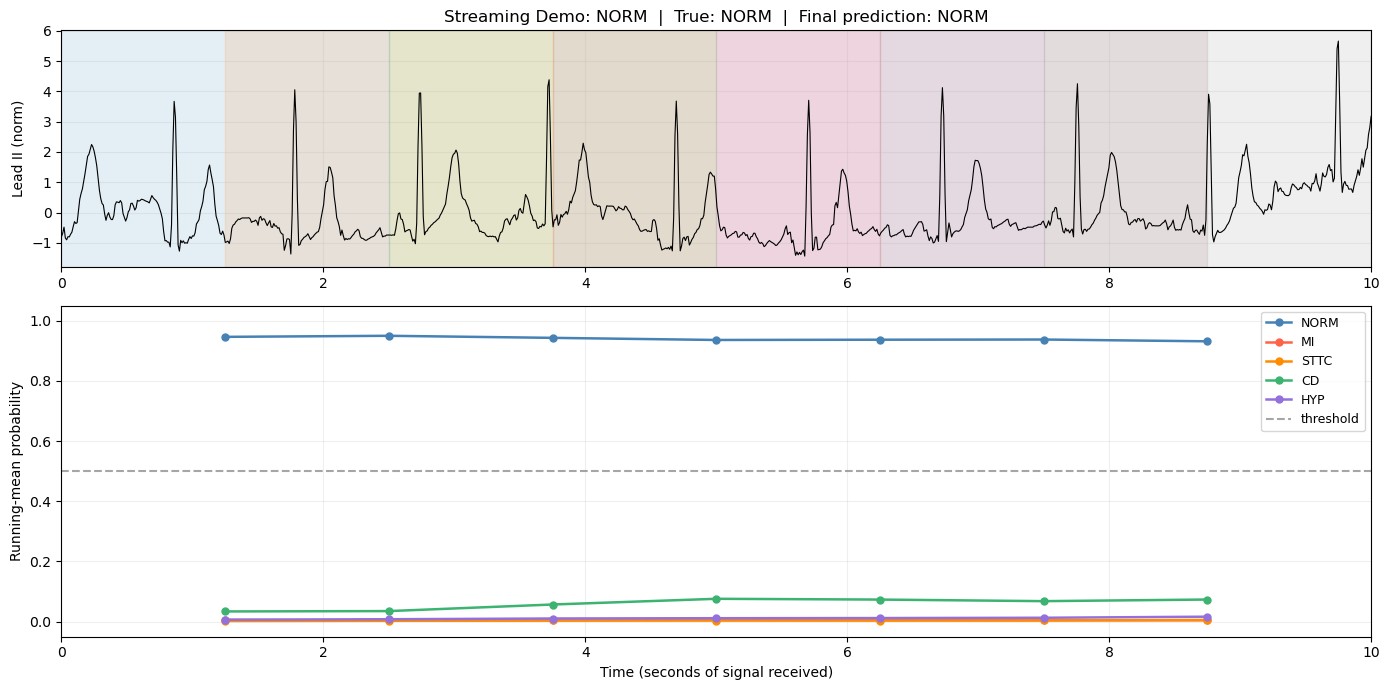

Saved -> D:\GitHub\biosignal-xai\results\figures/streaming_demo_NORM.png


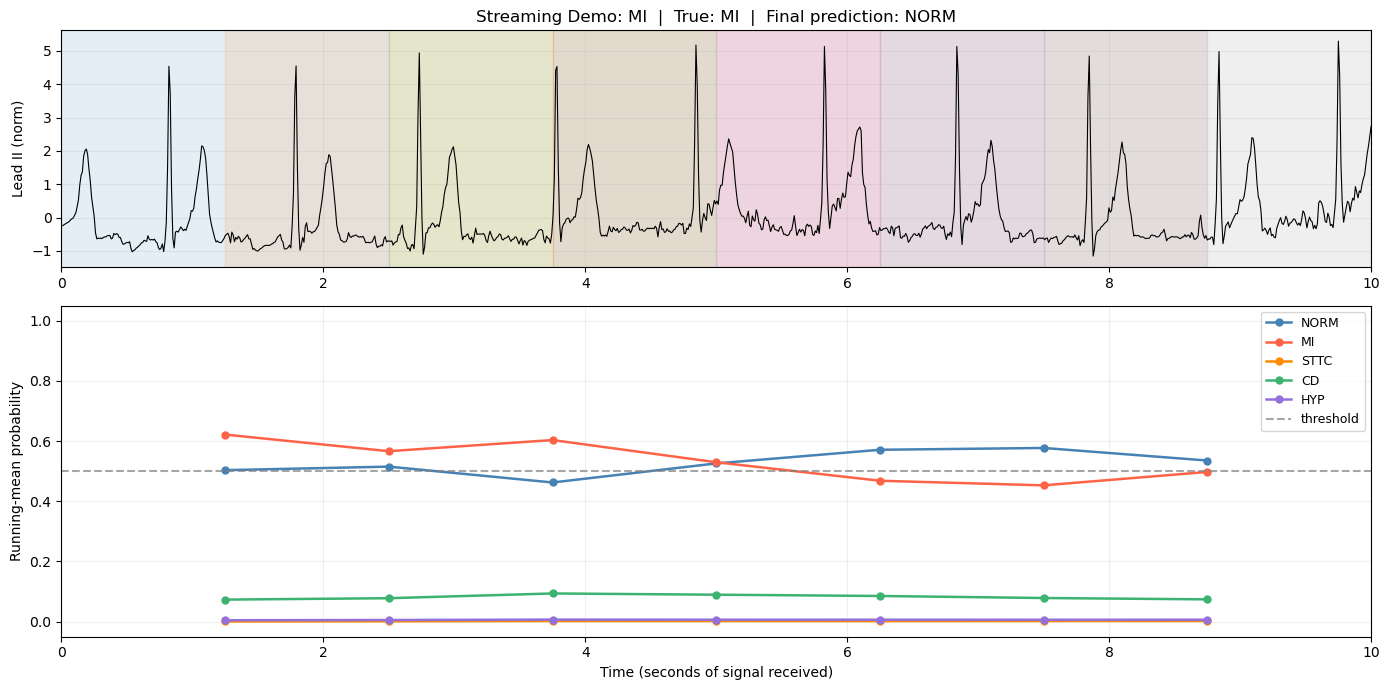

Saved -> D:\GitHub\biosignal-xai\results\figures/streaming_demo_MI.png


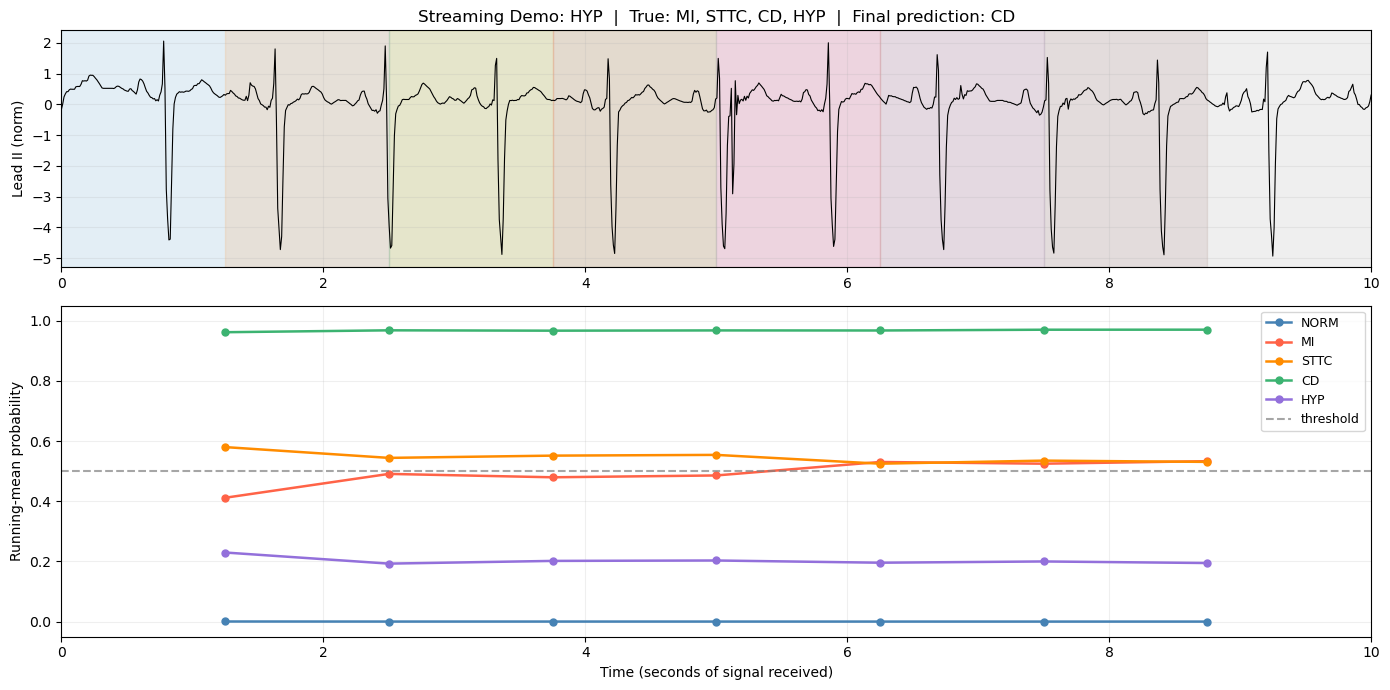

Saved -> D:\GitHub\biosignal-xai\results\figures/streaming_demo_HYP.png


In [5]:
def plot_streaming_demo(record_key, save_path=None):
    """
    Two-row figure per record:
      Row 1: Lead II signal with coloured window bands
      Row 2: Running-mean class probability evolution across windows
    """
    res     = stream_results[record_key]
    raw     = res['raw']         # (1000, 12)
    rp      = res['running_probs']  # (n_windows, 5)
    times   = res['window_times']   # start times in seconds
    true_cls= res['true_cls']
    n_win   = len(times)

    t_full  = np.linspace(0, 10, 1000)
    lead_II = raw[:, 1]          # Lead II is column index 1

    # Normalise for display
    lead_II = (lead_II - lead_II.mean()) / (lead_II.std() + 1e-8)

    # Window mid-points for x-axis of evolution plot
    win_mid = times + (WINDOW_SIZE / FS) / 2   # mid-time of each window

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                    gridspec_kw={'height_ratios': [1, 1.4]})

    # --- Row 1: ECG signal + window bands ---
    palette = plt.cm.tab10(np.linspace(0, 0.7, n_win))
    for k, (t_start, color) in enumerate(zip(times, palette)):
        ax1.axvspan(t_start, t_start + WINDOW_SIZE / FS,
                    alpha=0.12, color=color)
    ax1.plot(t_full, lead_II, color='black', linewidth=0.8)
    ax1.set_xlim(0, 10)
    ax1.set_ylabel('Lead II (norm)', fontsize=10)
    ax1.set_title(
        f'Streaming Demo: {record_key}  |  '
        f'True: {", ".join(true_cls)}  |  '
        f'Final prediction: {SUPERCLASSES[np.argmax(rp[-1])]}',
        fontsize=12
    )
    ax1.grid(True, alpha=0.2)

    # --- Row 2: probability evolution ---
    for i, cls in enumerate(SUPERCLASSES):
        ax2.plot(win_mid, rp[:, i],
                 marker='o', markersize=5,
                 color=CLASS_COLORS[i], linewidth=1.8,
                 label=cls)

    ax2.axhline(CFG['inference']['threshold'], linestyle='--',
                color='gray', alpha=0.7, label='threshold')
    ax2.set_xlim(0, 10)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_xlabel('Time (seconds of signal received)', fontsize=10)
    ax2.set_ylabel('Running-mean probability', fontsize=10)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


for record_key in stream_results:
    fp = os.path.join(FIGURES, f'streaming_demo_{record_key}.png')
    plot_streaming_demo(record_key, save_path=fp)
    print(f'Saved -> {fp}')

In [6]:
# Latency benchmark: GPU vs CPU, 200 passes after 10-pass warmup
N_BENCH  = 200
N_WARMUP = 10
dummy    = torch.randn(1, 12, 250)

def benchmark(model, input_tensor, dev_str, n_warmup, n_runs):
    dev = torch.device(dev_str)
    m   = model.to(dev)
    x   = input_tensor.to(dev)
    m.eval()
    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = m(x)
    if dev.type == 'cuda':
        torch.cuda.synchronize()
    # Timed runs
    latencies = []
    with torch.no_grad():
        for _ in range(n_runs):
            if dev.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _  = m(x)
            if dev.type == 'cuda':
                torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000)
    return np.array(latencies)


print(f'Benchmarking {N_BENCH} inference passes (warmup={N_WARMUP})...')
print()

results_bench = {}

if torch.cuda.is_available():
    gpu_lats = benchmark(cnn_model, dummy, 'cuda', N_WARMUP, N_BENCH)
    results_bench['GPU'] = gpu_lats
    print(f'GPU  | mean: {gpu_lats.mean():.3f} ms  '
          f'std: {gpu_lats.std():.3f} ms  '
          f'min: {gpu_lats.min():.3f} ms  '
          f'max: {gpu_lats.max():.3f} ms')
else:
    print('GPU : not available, skipping GPU benchmark')

cpu_lats = benchmark(cnn_model, dummy, 'cpu', N_WARMUP, N_BENCH)
results_bench['CPU'] = cpu_lats
print(f'CPU  | mean: {cpu_lats.mean():.3f} ms  '
      f'std: {cpu_lats.std():.3f} ms  '
      f'min: {cpu_lats.min():.3f} ms  '
      f'max: {cpu_lats.max():.3f} ms')

# Real-time threshold: inference must complete within the window stride interval
stride_ms = (STRIDE / FS) * 1000  # 1250 ms
print()
print(f'Window stride interval : {stride_ms:.0f} ms')
for dev_name, lats in results_bench.items():
    ok = 'YES' if lats.mean() < stride_ms else 'NO'
    print(f'{dev_name} real-time capable : {ok}  '
          f'(mean {lats.mean():.1f} ms vs {stride_ms:.0f} ms stride)')

Benchmarking 200 inference passes (warmup=10)...

GPU  | mean: 0.710 ms  std: 0.135 ms  min: 0.545 ms  max: 1.551 ms
CPU  | mean: 0.883 ms  std: 0.138 ms  min: 0.685 ms  max: 1.789 ms

Window stride interval : 1250 ms
GPU real-time capable : YES  (mean 0.7 ms vs 1250 ms stride)
CPU real-time capable : YES  (mean 0.9 ms vs 1250 ms stride)


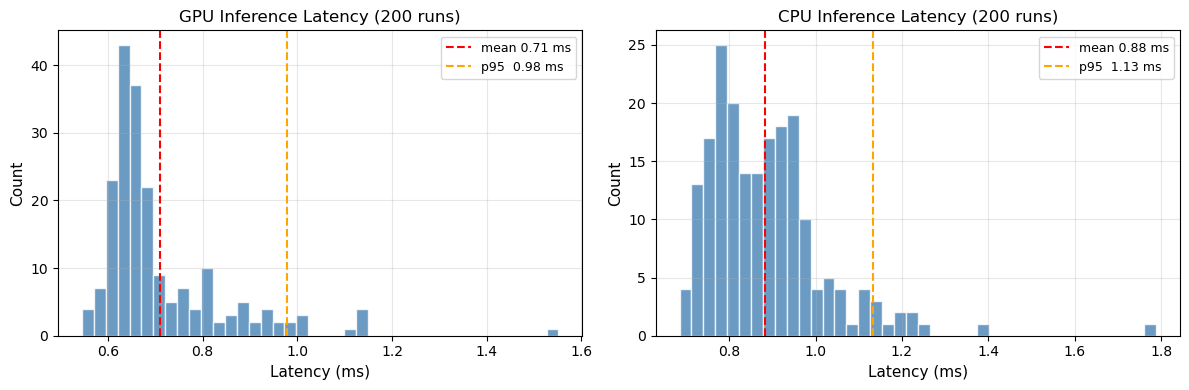

Saved -> D:\GitHub\biosignal-xai\results\figures/latency_distribution.png


In [7]:
# Latency distribution plot
n_panels = len(results_bench)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4), sharey=False)
if n_panels == 1:
    axes = [axes]

for ax, (dev_name, lats) in zip(axes, results_bench.items()):
    ax.hist(lats, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(lats.mean(), color='red',    linestyle='--', label=f'mean {lats.mean():.2f} ms')
    ax.axvline(np.percentile(lats, 95),
               color='orange', linestyle='--', label=f'p95  {np.percentile(lats, 95):.2f} ms')
    ax.set_xlabel('Latency (ms)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{dev_name} Inference Latency ({N_BENCH} runs)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fp = os.path.join(FIGURES, 'latency_distribution.png')
plt.savefig(fp, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fp}')

In [8]:
# Summary report
stride_ms = (STRIDE / FS) * 1000

print('=' * 60)
print('REAL-TIME STREAMING DEMO -- SUMMARY')
print('=' * 60)
print(f'Model       : BaselineCNN  |  {sum(p.numel() for p in cnn_model.parameters()):,} params')
print(f'Window      : {WINDOW_SIZE} samples = {WINDOW_SIZE/FS:.1f} s  '
      f'(stride {STRIDE} samples = {STRIDE/FS:.2f} s)')
print(f'Windows / 10-s record : {len(stream_results["NORM"]["window_probs"])}')
print()

print(f'{"Device":<8} {"Mean (ms)":>10} {"Std (ms)":>9} {"p95 (ms)":>9} {"Real-time?":>11}')
print('-' * 52)
for dev_name, lats in results_bench.items():
    rt  = 'YES' if lats.mean() < stride_ms else 'NO'
    p95 = np.percentile(lats, 95)
    print(f'{dev_name:<8} {lats.mean():>10.3f} {lats.std():>9.3f} {p95:>9.3f} {rt:>11}')
print('-' * 52)
print(f'Real-time threshold : {stride_ms:.0f} ms (one window stride)')
print()

print('Streaming prediction results:')
for record_key, res in stream_results.items():
    rp          = res['running_probs']
    final_pred  = SUPERCLASSES[np.argmax(rp[-1])]
    final_conf  = float(rp[-1].max())
    # Check if confidence crosses threshold at some point
    crossed_at  = next(
        (k+1 for k, p in enumerate(rp[:, np.argmax(rp[-1])]) if p >= CFG['inference']['threshold']),
        None
    )
    t_detect    = (res['window_times'][crossed_at - 1] if crossed_at else None)

    print(f'  {record_key:6}  true={res["true_cls"]}  '
          f'final_pred={final_pred}  conf={final_conf:.3f}  '
          f'threshold_crossed_at_window={crossed_at}  '
          f'(t={t_detect:.1f}s)' if t_detect is not None else '')
print()

# Save summary JSON
summary = {
    'window_size_samples': int(WINDOW_SIZE),
    'stride_samples':      int(STRIDE),
    'stride_ms':           float(stride_ms),
    'latency': {
        dev: {
            'mean_ms':   float(lats.mean()),
            'std_ms':    float(lats.std()),
            'p95_ms':    float(np.percentile(lats, 95)),
            'realtime':  bool(lats.mean() < stride_ms),
        }
        for dev, lats in results_bench.items()
    },
    'demo_records': {
        k: {
            'true_cls':    v['true_cls'],
            'final_pred':  SUPERCLASSES[int(np.argmax(v['running_probs'][-1]))],
            'final_conf':  float(v['running_probs'][-1].max()),
            'n_windows':   len(v['window_probs']),
        }
        for k, v in stream_results.items()
    },
}

out_path = os.path.join(RESULTS, 'realtime_demo_summary.json')
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved -> {out_path}')

REAL-TIME STREAMING DEMO -- SUMMARY
Model       : BaselineCNN  |  46,309 params
Window      : 250 samples = 2.5 s  (stride 125 samples = 1.25 s)
Windows / 10-s record : 7

Device    Mean (ms)  Std (ms)  p95 (ms)  Real-time?
----------------------------------------------------
GPU           0.710     0.135     0.978         YES
CPU           0.883     0.138     1.133         YES
----------------------------------------------------
Real-time threshold : 1250 ms (one window stride)

Streaming prediction results:
  NORM    true=['NORM']  final_pred=NORM  conf=0.931  threshold_crossed_at_window=1  (t=0.0s)
  MI      true=['MI']  final_pred=NORM  conf=0.535  threshold_crossed_at_window=1  (t=0.0s)
  HYP     true=['MI', 'STTC', 'CD', 'HYP']  final_pred=CD  conf=0.970  threshold_crossed_at_window=1  (t=0.0s)

Saved -> D:\GitHub\biosignal-xai\results/realtime_demo_summary.json
